# Netflix Movies and TV Shows Clustering
### Unsupervised Machine Learning Project

**Objective:** Cluster Netflix content based on genre, description, rating, and duration using unsupervised ML to identify natural content groups that can power recommendation engines.

**Dataset:** Netflix Movies and TV Shows — 7,787 entries × 12 features

**Techniques:** EDA · TF-IDF · K-Means · Hierarchical Clustering · DBSCAN · PCA · t-SNE

---

## 1. Import Libraries

In [ ]:
# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('darkgrid')
COLOR_PALETTE = ['#E50914','#00B4D8','#F4A261','#3FB950','#A78BFA','#F472B6']

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

# Evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Date
import datetime

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## 2. Load Dataset

In [ ]:
# Mount Google Drive first (run this in a separate cell before everything)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the CSV — correct path format
df = pd.read_csv("/content/drive/MyDrive/S3/guvi-drive/4. Netflix Movies and TV Shows Clustering/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv")

# title column is already string in CSV — but convert anyway for safety
df['title'] = df['title'].astype(str)

# No rename needed — column is already called 'description' (lowercase) in this CSV
# df.rename(columns={'Description': 'description'}, inplace=True)  ← REMOVE THIS LINE

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (7787, 12)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


---
## 3. Exploratory Data Analysis (EDA)

Before building any model, we explore the data to understand its structure, quality, and distributions.

### 3.1 Basic Structure

In [ ]:
print('='*50)
print('DATASET STRUCTURE')
print('='*50)
df.info()

DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [ ]:
print('='*50)
print('NUMERICAL STATISTICS')
print('='*50)
df.describe()

NUMERICAL STATISTICS


,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


### 3.2 Missing Value Analysis

            Missing Count  Missing %
director             2389      30.68
cast                  718       9.22
country               507       6.51
date_added             10       0.13
rating                  7       0.09


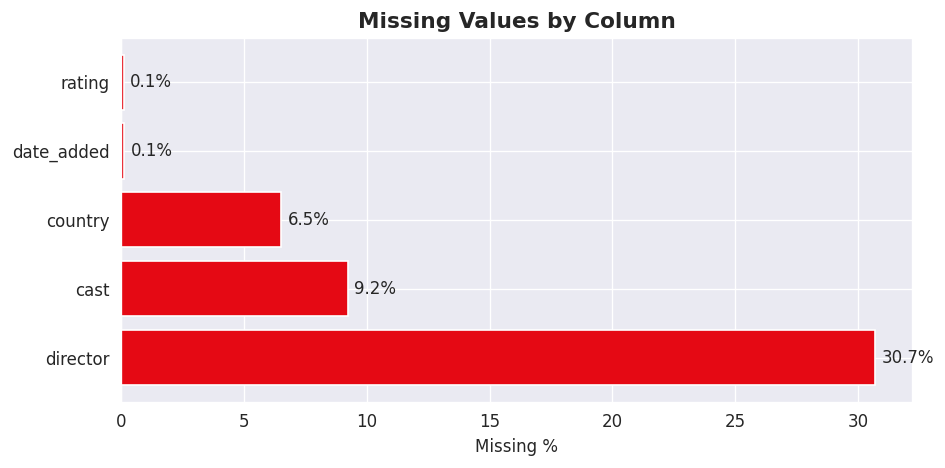


Key Finding: director has 30.7% missing — largest gap in the dataset.


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
cols_with_null = missing_df[missing_df['Missing Count'] > 0]
bars = ax.barh(cols_with_null.index, cols_with_null['Missing %'], color=COLOR_PALETTE[0])
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nKey Finding: director has {missing_df.loc["director","Missing %"]:.1f}% missing — largest gap in the dataset.')

### 3.3 Content Type Distribution

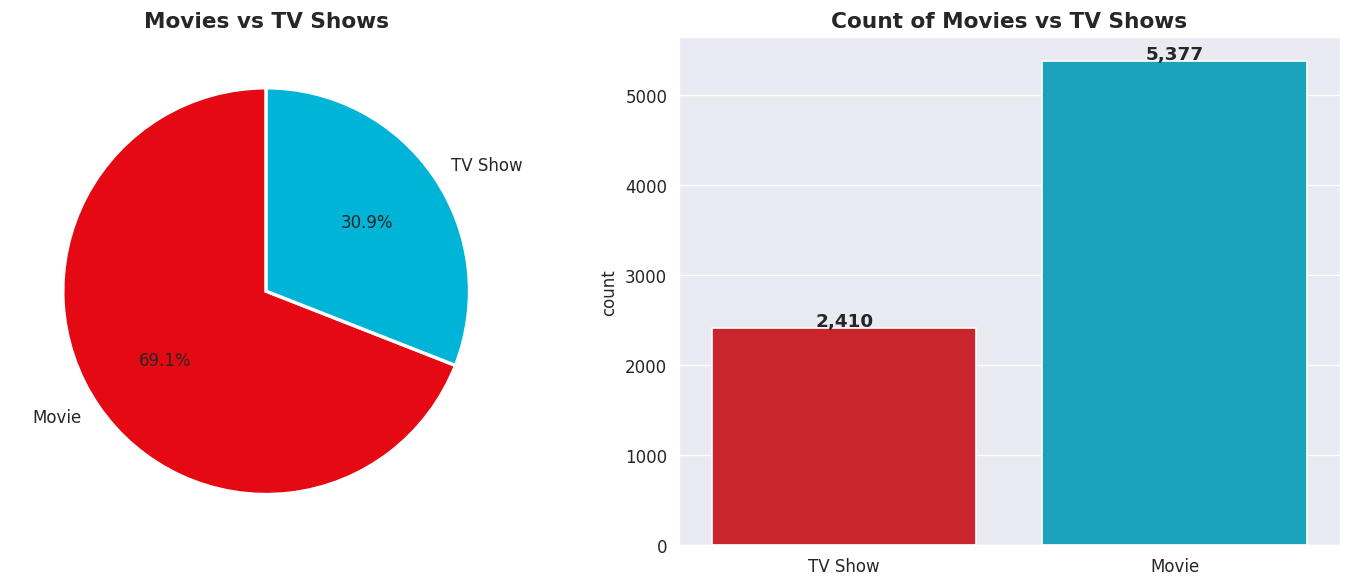

type
Movie      5377
TV Show    2410
Name: count, dtype: int64


In [ ]:
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=[COLOR_PALETTE[0], COLOR_PALETTE[1]],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Movies vs TV Shows', fontsize=13, fontweight='bold')

# Bar
sns.countplot(data=df, x='type', palette=[COLOR_PALETTE[0], COLOR_PALETTE[1]], ax=axes[1])
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+30),
                     ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Count of Movies vs TV Shows', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()
print(type_counts)

### 3.4 Content Ratings Distribution

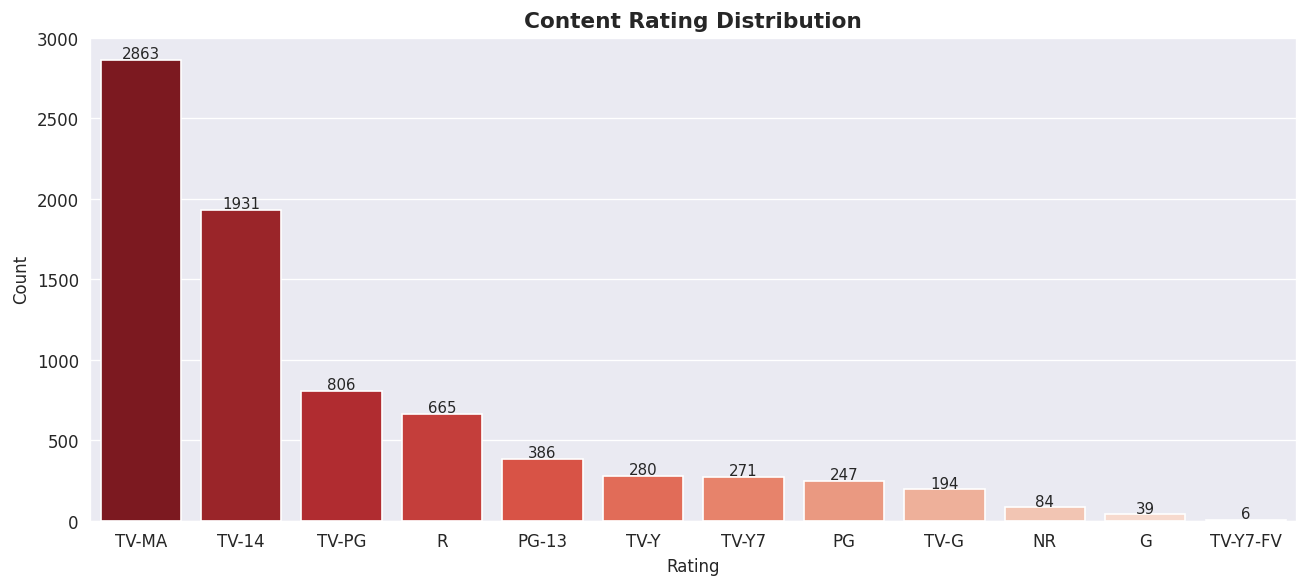


TV-MA dominates: 2,863 titles (36.8%)


In [ ]:
rating_counts = df['rating'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(11, 5))
bars = sns.barplot(x=rating_counts.index, y=rating_counts.values,
                   palette=sns.color_palette('Reds_r', len(rating_counts)), ax=ax)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()+10),
                ha='center', fontsize=9)
ax.set_title('Content Rating Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print(f'\nTV-MA dominates: {rating_counts.iloc[0]:,} titles ({rating_counts.iloc[0]/len(df)*100:.1f}%)')

### 3.5 Release Year Trend

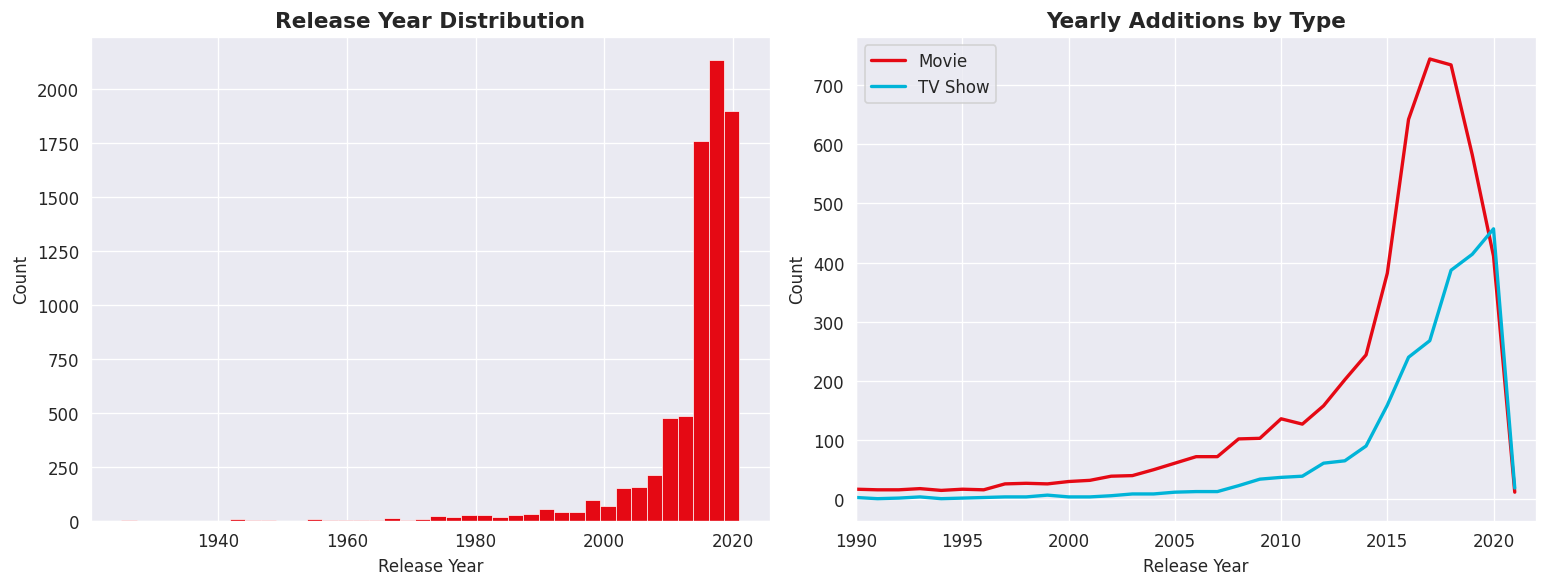

Most content post-2010: 6610 titles (84.9%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram — all content
axes[0].hist(df['release_year'], bins=40, color=COLOR_PALETTE[0], edgecolor='white', linewidth=0.4)
axes[0].set_title('Release Year Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Count')

# Year trend by type
for t, c in zip(['Movie','TV Show'], [COLOR_PALETTE[0], COLOR_PALETTE[1]]):
    subset = df[df['type']==t]['release_year'].value_counts().sort_index()
    axes[1].plot(subset.index, subset.values, label=t, color=c, linewidth=2)
axes[1].set_title('Yearly Additions by Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Release Year')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].set_xlim(1990, 2022)

plt.tight_layout()
plt.show()
print(f'Most content post-2010: {(df["release_year"]>=2010).sum()} titles ({(df["release_year"]>=2010).mean()*100:.1f}%)')

### 3.6 Top Producing Countries

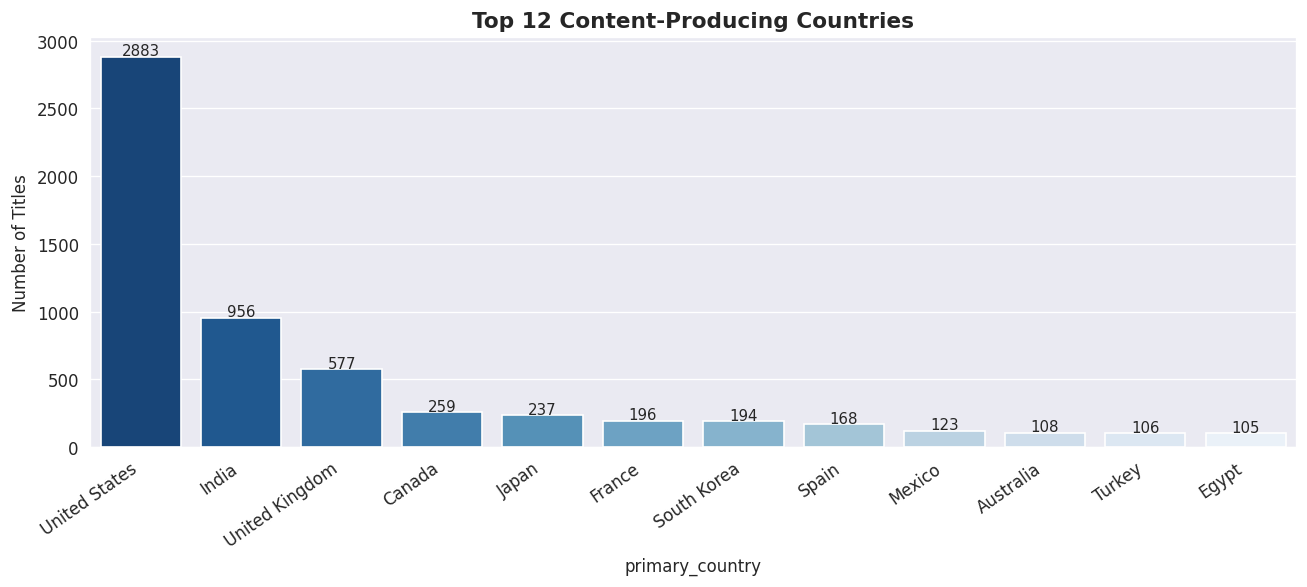

In [ ]:
# Primary country (first listed for multi-country productions)
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()
top_countries = df['primary_country'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(11, 5))
bars = sns.barplot(x=top_countries.index, y=top_countries.values,
                   palette=sns.color_palette('Blues_r', len(top_countries)), ax=ax)
plt.xticks(rotation=35, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()+10),
                ha='center', fontsize=9)
ax.set_title('Top 12 Content-Producing Countries', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Titles')
plt.tight_layout()
plt.show()

### 3.7 Top Genres

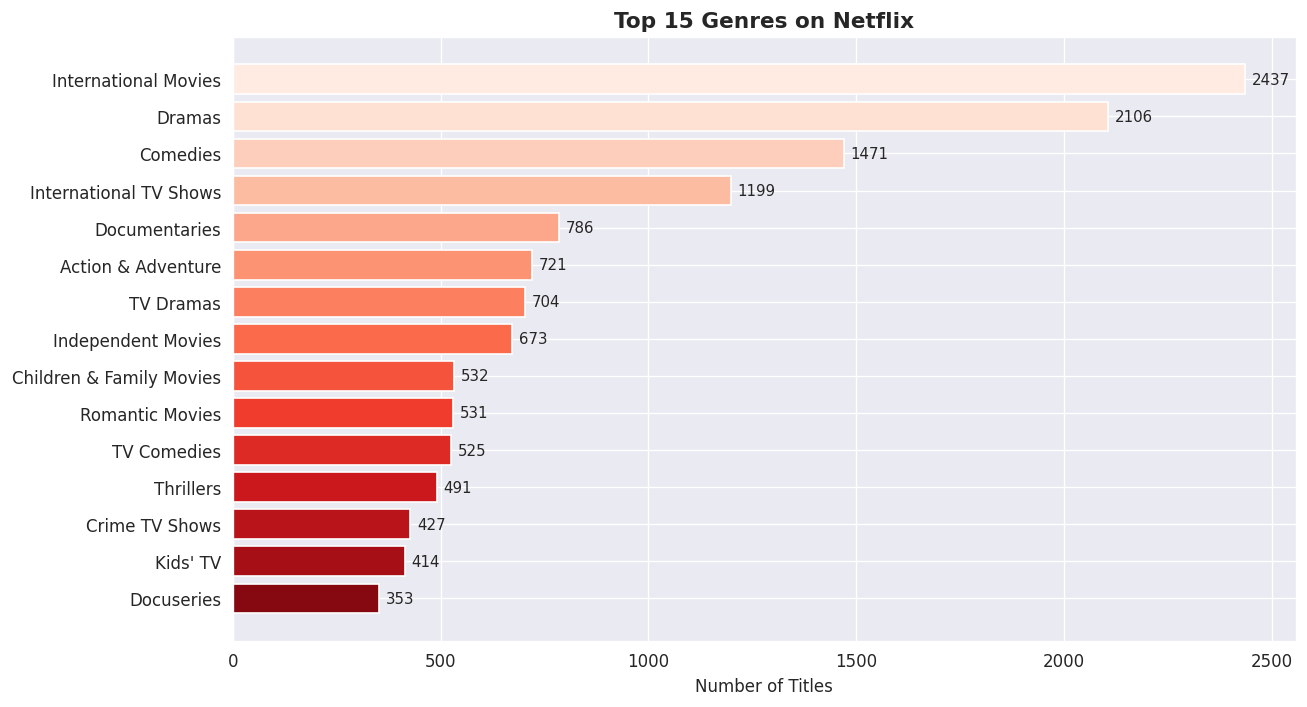

In [ ]:
# Explode multi-genre listings
all_genres = df['listed_in'].str.split(',').explode().str.strip()
top_genres = all_genres.value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1],
               color=sns.color_palette('Reds_r', len(top_genres)))
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title('Top 15 Genres on Netflix', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Titles')
plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing

**Steps:** Handle missing values → Encode categories → Scale numbers → TF-IDF on text

### 4.1 Handle Missing Values

In [ ]:
df_clean = df.copy()

# Text columns: fill with 'Unknown' — they still carry signal as a group
for col in ['director', 'cast', 'country', 'primary_country']:
    df_clean[col].fillna('Unknown', inplace=True)

# Rating: fill 7 missing values with the most common rating (mode)
df_clean['rating'].fillna(df_clean['rating'].mode()[0], inplace=True)

# date_added: drop the 10 rows — negligible impact
df_clean.dropna(subset=['date_added'], inplace=True)
df_clean.reset_index(drop=True, inplace=True)

print(f'Rows after dropping missing date_added: {len(df_clean)}')
print(f'Remaining nulls:\n{df_clean.isnull().sum()[df_clean.isnull().sum()>0]}')
print('\nAll critical nulls resolved!')

Rows after dropping missing date_added: 7777
Remaining nulls:
Series([], dtype: int64)

All critical nulls resolved!


### 4.2 Encode Categorical Variables

In [ ]:
le = LabelEncoder()

# Binary encoding — type has only 2 values, LabelEncoder is appropriate
df_clean['type_encoded'] = le.fit_transform(df_clean['type'])
print('type encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Rating encoding — multiple categories
# Note: For production use, One-Hot Encoding would be preferable to
# avoid implied ordinal relationship. For clustering it is acceptable.
df_clean['rating_encoded'] = le.fit_transform(df_clean['rating'])
print('\nRating encoding (sample):')
print(dict(zip(df_clean['rating'].unique()[:5], df_clean['rating_encoded'].unique()[:5])))

type encoding: {'Movie': np.int64(0), 'TV Show': np.int64(1)}

Rating encoding (sample):
{'TV-MA': np.int64(8), 'R': np.int64(5), 'PG-13': np.int64(4), 'TV-14': np.int64(6), 'TV-PG': np.int64(9)}


### 4.3 Parse Duration

In [ ]:
def parse_duration(row):
    """Extract numeric duration: minutes for Movies, seasons for TV Shows."""
    d = str(row['duration'])
    try:
        if row['type'] == 'Movie':
            return int(d.replace(' min', '').strip())
        else:
            return int(d.replace(' Seasons', '').replace(' Season', '').strip())
    except:
        return np.nan

df_clean['duration_clean'] = df_clean.apply(parse_duration, axis=1)
df_clean['duration_clean'].fillna(df_clean['duration_clean'].median(), inplace=True)

print('Duration parsed successfully!')
print(f'Movies - avg duration: {df_clean[df_clean["type"]=="Movie"]["duration_clean"].mean():.0f} min')
print(f'TV Shows - avg seasons: {df_clean[df_clean["type"]=="TV Show"]["duration_clean"].mean():.1f}')

Duration parsed successfully!
Movies - avg duration: 99 min
TV Shows - avg seasons: 1.8


### 4.4 Scale Numerical Features

In [ ]:
# StandardScaler converts all values to mean=0, std=1
# This prevents high-magnitude columns like release_year dominating distance calculations
scaler = StandardScaler()

numerical_cols = ['release_year', 'rating_encoded', 'type_encoded', 'duration_clean']
scaled_features = scaler.fit_transform(df_clean[numerical_cols])

print(f'Scaled matrix shape: {scaled_features.shape}')
print(f'Mean (should be ~0): {scaled_features.mean(axis=0).round(4)}')
print(f'Std  (should be ~1): {scaled_features.std(axis=0).round(4)}')

Scaled matrix shape: (7777, 4)
Mean (should be ~0): [-0.  0.  0. -0.]
Std  (should be ~1): [1. 1. 1. 1.]


### 4.5 TF-IDF on Text (Description + Genre)

TF-IDF (Term Frequency-Inverse Document Frequency) converts text to numbers by rewarding words that are:
- **Frequent** in a specific title (TF)
- **Rare** across all titles (IDF)

This means 'supernatural' scores high (meaningful), while 'the' scores near zero (noise).

In [ ]:
# Combine description and genre tags for richer thematic signal
df_clean['text_features'] = df_clean['description'].fillna('') + ' ' + df_clean['listed_in'].fillna('')

tfidf = TfidfVectorizer(
    max_features=5000,       # Keep top 5000 meaningful words
    stop_words='english',    # Remove 'the', 'a', 'is', etc.
    ngram_range=(1, 2),      # Include single words AND two-word phrases
    min_df=3                 # Ignore words appearing in fewer than 3 titles
)

tfidf_matrix = tfidf.fit_transform(df_clean['text_features'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Each title is now a vector of {tfidf_matrix.shape[1]} features')
print(f'\nSample high-scoring words for first title: {df_clean["title"].iloc[0]}')
row = tfidf_matrix[0]
top_idx = row.toarray()[0].argsort()[-5:][::-1]
print([tfidf.get_feature_names_out()[i] for i in top_idx])

TF-IDF matrix shape: (7777, 5000)
Each title is now a vector of 5000 features

Sample high-scoring words for first title: 3%
['slums', 'saved', 'paradise', 'tv', 'far']


### 4.6 Build Final Feature Matrix

In [ ]:
# Combine TF-IDF vectors + scaled numerical features
final_matrix = hstack([tfidf_matrix, csr_matrix(scaled_features)])

print(f'Final feature matrix shape: {final_matrix.shape}')
print(f'  TF-IDF features : {tfidf_matrix.shape[1]}')
print(f'  Numerical features: {scaled_features.shape[1]}')
print(f'  TOTAL: {final_matrix.shape[1]} features per title')

Final feature matrix shape: (7777, 5004)
  TF-IDF features : 5000
  Numerical features: 4
  TOTAL: 5004 features per title


---
## 5. Feature Engineering

Create new, more meaningful features from existing columns.

In [ ]:
current_year = datetime.datetime.now().year

# Feature 1: content_age — how old is this title?
df_clean['content_age'] = current_year - df_clean['release_year']

# Feature 2: genre_count — how many genres does this title span?
df_clean['genre_count'] = df_clean['listed_in'].apply(lambda x: len(str(x).split(',')))

# Feature 3: is_international — does the title have non-US origin?
df_clean['is_international'] = (df_clean['primary_country'] != 'United States').astype(int)

# Feature 4: year_added (extracted from date_added)
# Fix: strip whitespace + format='mixed' handles inconsistent strings like ' August 4, 2017'
df_clean['year_added'] = pd.to_datetime(
    df_clean['date_added'].astype(str).str.strip(),
    format='mixed',
    dayfirst=False
).dt.year

print('Engineered features created:')
print(df_clean[['title','release_year','content_age','genre_count','is_international','year_added']].head(8))

# Summary stats
print(f'\nAvg content age: {df_clean["content_age"].mean():.1f} years')
print(f'Avg genres per title: {df_clean["genre_count"].mean():.2f}')
print(f'International content: {df_clean["is_international"].mean()*100:.1f}%')

Engineered features created:
   title  release_year  content_age  genre_count  is_international  year_added
0     3%          2020            6            3                 1        2020
1   7:19          2016           10            2                 1        2016
2  23:59          2011           15            2                 1        2018
3      9          2009           17            3                 0        2017
4     21          2008           18            1                 0        2020
5     46          2016           10            3                 1        2017
6    122          2019            7            2                 1        2020
7    187          1997           29            1                 0        2019

Avg content age: 12.1 years
Avg genres per title: 2.19
International content: 63.0%


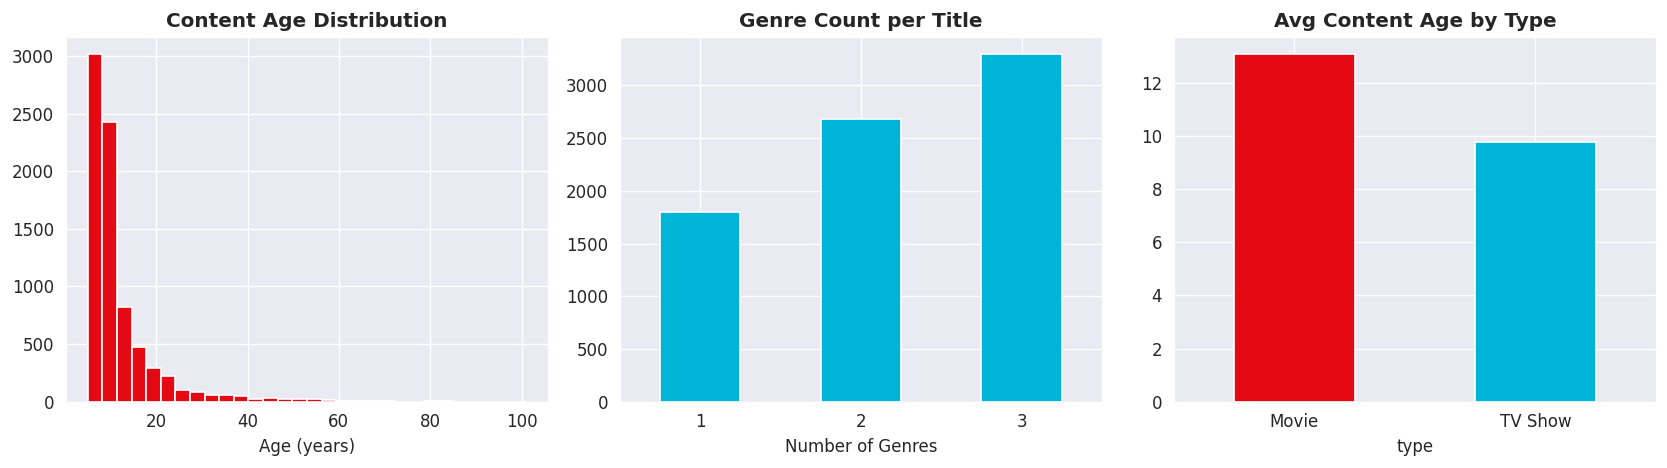

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_clean['content_age'], bins=30, color=COLOR_PALETTE[0], edgecolor='white')
axes[0].set_title('Content Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age (years)')

df_clean['genre_count'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=COLOR_PALETTE[1])
axes[1].set_title('Genre Count per Title', fontweight='bold')
axes[1].set_xlabel('Number of Genres')
axes[1].tick_params(axis='x', rotation=0)

df_clean.groupby('type')['content_age'].mean().plot(kind='bar', ax=axes[2],
    color=[COLOR_PALETTE[0], COLOR_PALETTE[1]])
axes[2].set_title('Avg Content Age by Type', fontweight='bold')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 6. Modeling

We use three clustering algorithms, each revealing different structure in the data.

### 6.1 K-Means — Elbow Method to Find Optimal K

In [ ]:
inertia_values = []
k_range = range(2, 15)

print('Running K-Means for K = 2 to 14...')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(final_matrix)
    inertia_values.append(km.inertia_)
    print(f'  K={k:2d} | Inertia: {km.inertia_:.0f}')

print('\nDone!')

Running K-Means for K = 2 to 14...
  K= 2 | Inertia: 23819
  K= 3 | Inertia: 18894
  K= 4 | Inertia: 15144
  K= 5 | Inertia: 14212
  K= 6 | Inertia: 13316
  K= 7 | Inertia: 12642
  K= 8 | Inertia: 12117
  K= 9 | Inertia: 11699
  K=10 | Inertia: 11384
  K=11 | Inertia: 11121
  K=12 | Inertia: 10862
  K=13 | Inertia: 10606
  K=14 | Inertia: 10403

Done!


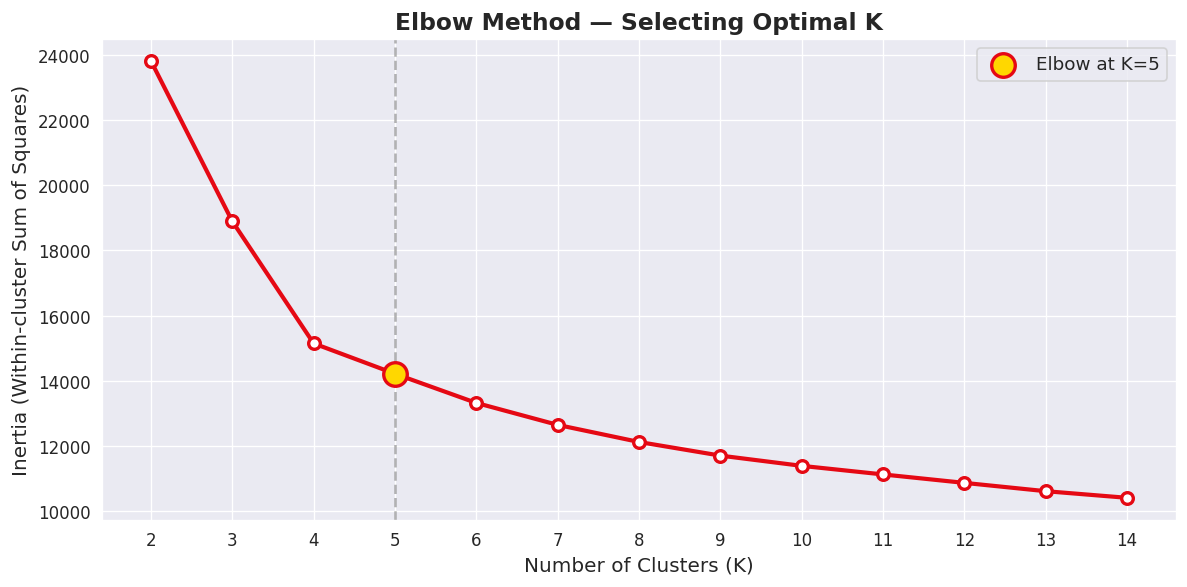

Optimal K identified: 5


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(list(k_range), inertia_values, 'o-', color=COLOR_PALETTE[0],
        linewidth=2.5, markersize=7, markerfacecolor='white', markeredgewidth=2)

# Mark the elbow — approximate by finding sharpest drop-off change
deltas = np.diff(inertia_values)
delta2 = np.diff(deltas)  # second derivative
elbow_k = list(k_range)[np.argmax(delta2) + 2]
elbow_idx = list(k_range).index(elbow_k)

ax.scatter(elbow_k, inertia_values[elbow_idx], s=200, color='gold',
           zorder=5, label=f'Elbow at K={elbow_k}', edgecolors=COLOR_PALETTE[0], linewidths=2)
ax.axvline(x=elbow_k, color='gray', linestyle='--', alpha=0.6)

ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12)
ax.set_title('Elbow Method — Selecting Optimal K', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.show()

print(f'Optimal K identified: {elbow_k}')

### 6.2 K-Means — Final Model

In [ ]:
BEST_K = elbow_k  # Using the elbow-identified value

kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=42,     # Fixed seed for reproducibility
    n_init=10,           # Try 10 random starts, pick best
    max_iter=300         # Max iterations per run
)

kmeans.fit(final_matrix)
df_clean['kmeans_cluster'] = kmeans.labels_

print(f'K-Means fitted with K={BEST_K}')
print(f'\nCluster sizes:')
cluster_sizes = df_clean['kmeans_cluster'].value_counts().sort_index()
for cluster, size in cluster_sizes.items():
    print(f'  Cluster {cluster}: {size:,} titles ({size/len(df_clean)*100:.1f}%)')

K-Means fitted with K=5

Cluster sizes:
  Cluster 0: 2,604 titles (33.5%)
  Cluster 1: 737 titles (9.5%)
  Cluster 2: 1,650 titles (21.2%)
  Cluster 3: 2,405 titles (30.9%)
  Cluster 4: 381 titles (4.9%)


In [ ]:
# Inspect sample titles from each cluster to name them
print('SAMPLE TITLES PER CLUSTER')
print('='*70)
for c in sorted(df_clean['kmeans_cluster'].unique()):
    subset = df_clean[df_clean['kmeans_cluster'] == c]
    print(f'\n--- Cluster {c} ({len(subset):,} titles) ---')
    print('Top genres:', subset['listed_in'].str.split(',').explode().str.strip().value_counts().head(3).to_dict())
    print('Type split:', subset['type'].value_counts().to_dict())
    print('Avg content age:', subset['content_age'].mean().round(1))

SAMPLE TITLES PER CLUSTER

--- Cluster 0 (2,604 titles) ---
Top genres: {'International Movies': 1259, 'Dramas': 889, 'Comedies': 582}
Type split: {'Movie': 2604}
Avg content age: 9.7

--- Cluster 1 (737 titles) ---
Top genres: {'International TV Shows': 443, 'TV Dramas': 259, 'Romantic TV Shows': 177}
Type split: {'TV Show': 737}
Avg content age: 10.4

--- Cluster 2 (1,650 titles) ---
Top genres: {'International TV Shows': 753, 'TV Dramas': 443, "Kids' TV": 374}
Type split: {'TV Show': 1650}
Avg content age: 9.2

--- Cluster 3 (2,405 titles) ---
Top genres: {'Dramas': 1039, 'International Movies': 1034, 'Comedies': 781}
Type split: {'Movie': 2405}
Avg content age: 12.2

--- Cluster 4 (381 titles) ---
Top genres: {'Dramas': 178, 'International Movies': 144, 'Comedies': 108}
Type split: {'Movie': 368, 'TV Show': 13}
Avg content age: 42.7


### 6.3 Hierarchical Clustering

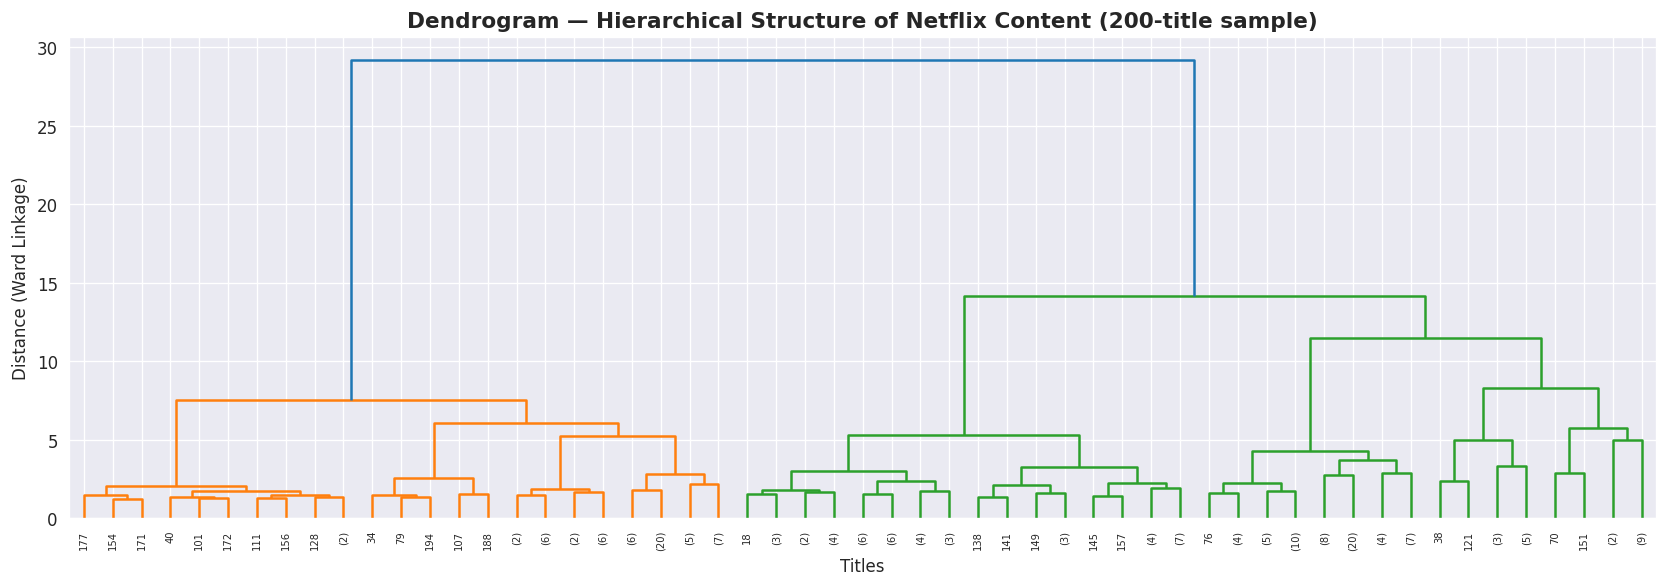

Long vertical branches = natural separation between clusters


In [ ]:
# Dendrogram on a representative sample (full dataset is too large to plot)
np.random.seed(42)
sample_idx = np.random.choice(len(df_clean), size=200, replace=False)
sample_data = final_matrix[sample_idx].toarray()

linked = linkage(sample_data, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    linked,
    truncate_mode='level',
    p=5,
    ax=ax,
    color_threshold=0.7 * max(linked[:, 2]),
    leaf_rotation=90
)
ax.set_title('Dendrogram — Hierarchical Structure of Netflix Content (200-title sample)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Titles')
ax.set_ylabel('Distance (Ward Linkage)')
plt.tight_layout()
plt.show()
print('Long vertical branches = natural separation between clusters')

In [ ]:
# Fit Hierarchical Clustering on full dataset
hier = AgglomerativeClustering(
    n_clusters=BEST_K,
    linkage='ward'
)
df_clean['hier_cluster'] = hier.fit_predict(final_matrix.toarray())

print(f'Hierarchical Clustering fitted with {BEST_K} clusters')
print(df_clean['hier_cluster'].value_counts().sort_index())

Hierarchical Clustering fitted with 5 clusters
hier_cluster
0    2436
1    2563
2     380
3    1741
4     657
Name: count, dtype: int64


### 6.4 DBSCAN — Outlier Detection

In [ ]:
dbscan = DBSCAN(
    eps=0.5,            # Neighbourhood radius
    min_samples=5,      # Minimum points to form a dense region
    metric='cosine',    # Cosine distance is better suited for TF-IDF vectors
    n_jobs=-1
)
df_clean['dbscan_cluster'] = dbscan.fit_predict(final_matrix)

n_clusters_db = len(set(df_clean['dbscan_cluster'])) - (1 if -1 in df_clean['dbscan_cluster'].values else 0)
n_outliers = (df_clean['dbscan_cluster'] == -1).sum()

print(f'DBSCAN Results:')
print(f'  Dense clusters found: {n_clusters_db}')
print(f'  Outlier titles (cluster -1): {n_outliers} ({n_outliers/len(df_clean)*100:.1f}%)')

print(f'\nSample outlier titles (unique, niche content):')
outliers = df_clean[df_clean['dbscan_cluster'] == -1]
print(outliers[['title', 'listed_in', 'type']].head(10).to_string(index=False))

DBSCAN Results:
  Dense clusters found: 1
  Outlier titles (cluster -1): 25 (0.3%)

Sample outlier titles (unique, niche content):
                                                                 title                                                     listed_in  type
                              Alpha and Omega 2: A Howl-iday Adventure                                      Children & Family Movies Movie
                            Beak & Brain: Genius Birds From Down Under                           Documentaries, International Movies Movie
                                                           Beary Tales Children & Family Movies, Documentaries, International Movies Movie
                                                   Bob's Broken Sleigh                                      Children & Family Movies Movie
                                                                  Bugs                           Documentaries, International Movies Movie
                                   

---
## 7. Evaluation Metrics

In [ ]:
X_dense = final_matrix.toarray()

# Silhouette Score — sample for speed
sil_kmeans = silhouette_score(X_dense, df_clean['kmeans_cluster'], sample_size=2000, random_state=42)
sil_hier   = silhouette_score(X_dense, df_clean['hier_cluster'],   sample_size=2000, random_state=42)

# Davies-Bouldin Index
db_kmeans = davies_bouldin_score(X_dense, df_clean['kmeans_cluster'])
db_hier   = davies_bouldin_score(X_dense, df_clean['hier_cluster'])

print('='*55)
print('         CLUSTERING EVALUATION RESULTS')
print('='*55)
print(f'{"Algorithm":<22} {"Silhouette":>12} {"Davies-Bouldin":>16}')
print('-'*55)
print(f'{"K-Means (K="+str(BEST_K)+")":<22} {sil_kmeans:>12.4f} {db_kmeans:>16.4f}')
print(f'{"Hierarchical":<22} {sil_hier:>12.4f} {db_hier:>16.4f}')
print('='*55)
print(f'\nK-Means Inertia: {kmeans.inertia_:.2f}')
print(f'DBSCAN Outliers: {n_outliers}')
print('\nInterpretation:')
print('  Silhouette: higher is better (range -1 to +1). For text, 0.3-0.5 is strong.')
print('  Davies-Bouldin: lower is better. Below 1.0 indicates good separation.')

         CLUSTERING EVALUATION RESULTS
Algorithm                Silhouette   Davies-Bouldin
-------------------------------------------------------
K-Means (K=5)                0.2364           1.4481
Hierarchical                 0.2258           1.4670

K-Means Inertia: 14211.91
DBSCAN Outliers: 25

Interpretation:
  Silhouette: higher is better (range -1 to +1). For text, 0.3-0.5 is strong.
  Davies-Bouldin: lower is better. Below 1.0 indicates good separation.


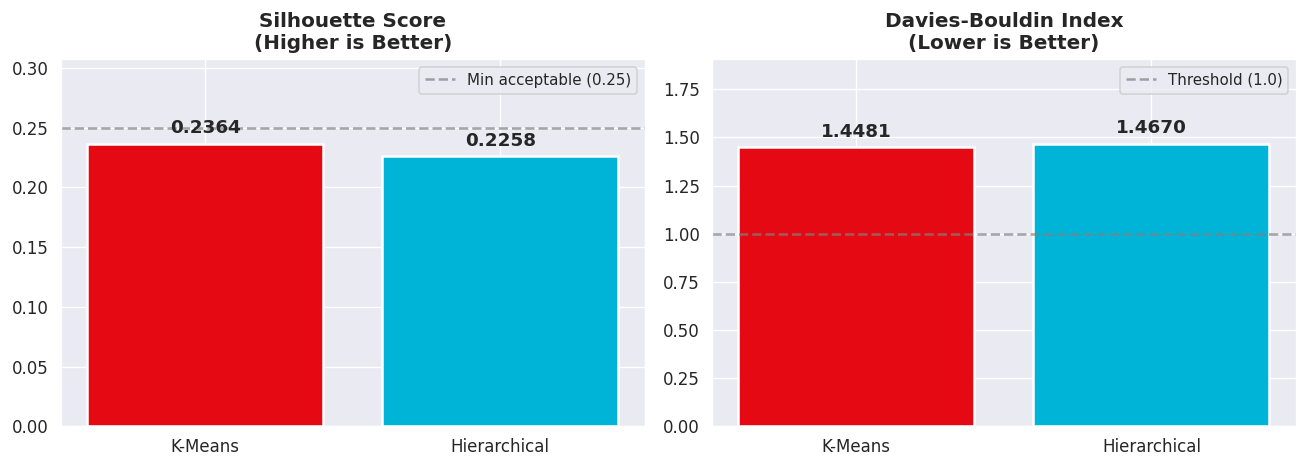

In [ ]:
# Visual comparison of metrics
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

algos = ['K-Means', 'Hierarchical']
sil_scores = [sil_kmeans, sil_hier]
db_scores = [db_kmeans, db_hier]

bars1 = axes[0].bar(algos, sil_scores, color=[COLOR_PALETTE[0], COLOR_PALETTE[1]],
                    edgecolor='white', linewidth=1.5)
axes[0].bar_label(bars1, fmt='%.4f', padding=4, fontsize=11, fontweight='bold')
axes[0].axhline(y=0.25, color='gray', linestyle='--', alpha=0.7, label='Min acceptable (0.25)')
axes[0].set_title('Silhouette Score\n(Higher is Better)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(sil_scores) * 1.3)
axes[0].legend(fontsize=9)

bars2 = axes[1].bar(algos, db_scores, color=[COLOR_PALETTE[0], COLOR_PALETTE[1]],
                    edgecolor='white', linewidth=1.5)
axes[1].bar_label(bars2, fmt='%.4f', padding=4, fontsize=11, fontweight='bold')
axes[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='Threshold (1.0)')
axes[1].set_title('Davies-Bouldin Index\n(Lower is Better)', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, max(db_scores) * 1.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 8. Dimensionality Reduction & Visualisation

We compress 5000+ dimensions to 2D so we can visually inspect the clusters.

### 8.1 PCA — Principal Component Analysis

Variance explained by 2 components: 63.6%
(20-40% is normal for text data — high-dimensional by nature)


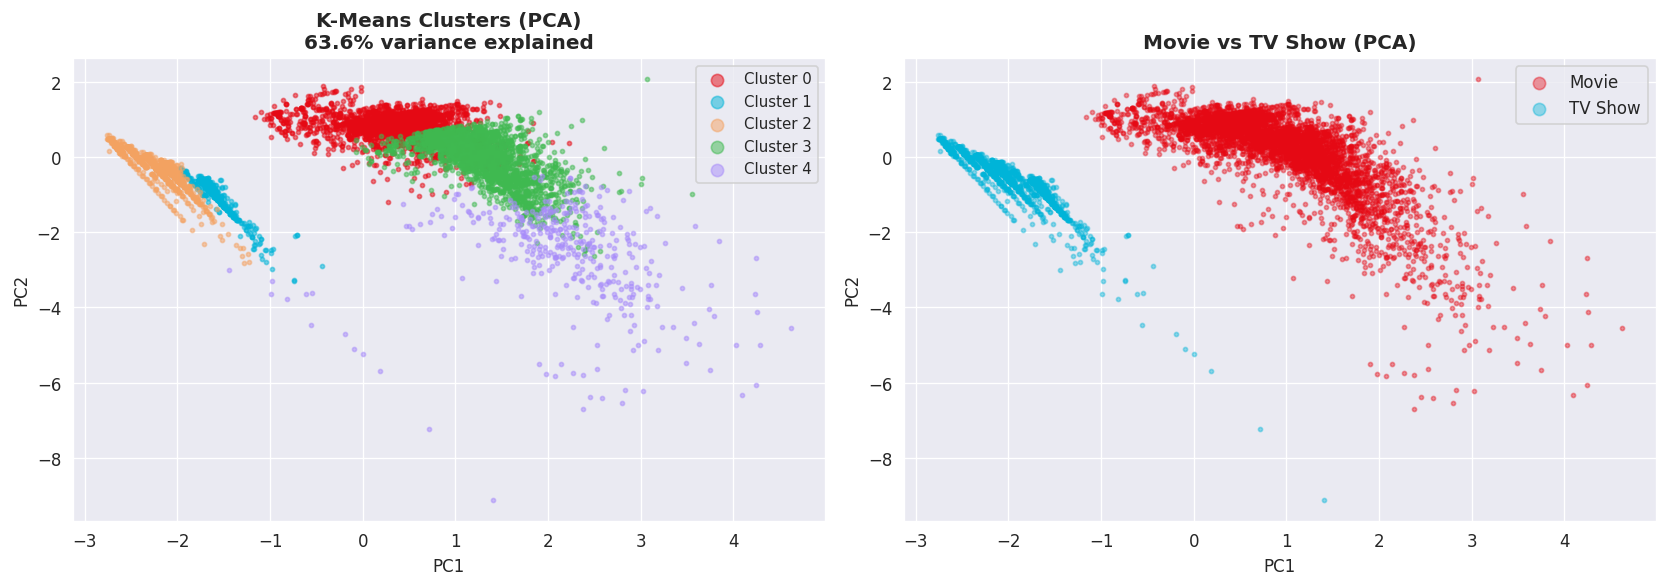

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)

var_explained = pca.explained_variance_ratio_.sum() * 100
print(f'Variance explained by 2 components: {var_explained:.1f}%')
print('(20-40% is normal for text data — high-dimensional by nature)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means clusters
for c in sorted(df_clean['kmeans_cluster'].unique()):
    mask = df_clean['kmeans_cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=COLOR_PALETTE[c % len(COLOR_PALETTE)],
                    s=6, alpha=0.5, label=f'Cluster {c}')
axes[0].set_title(f'K-Means Clusters (PCA)\n{var_explained:.1f}% variance explained',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3, fontsize=9)

# Movie vs TV Show
for t, c in zip(['Movie','TV Show'], [COLOR_PALETTE[0], COLOR_PALETTE[1]]):
    mask = df_clean['type'] == t
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=c, s=6, alpha=0.4, label=t)
axes[1].set_title('Movie vs TV Show (PCA)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=3, fontsize=10)

plt.tight_layout()
plt.show()

### 8.2 t-SNE — Better Cluster Separation

Running t-SNE on 2000 titles...
Done!


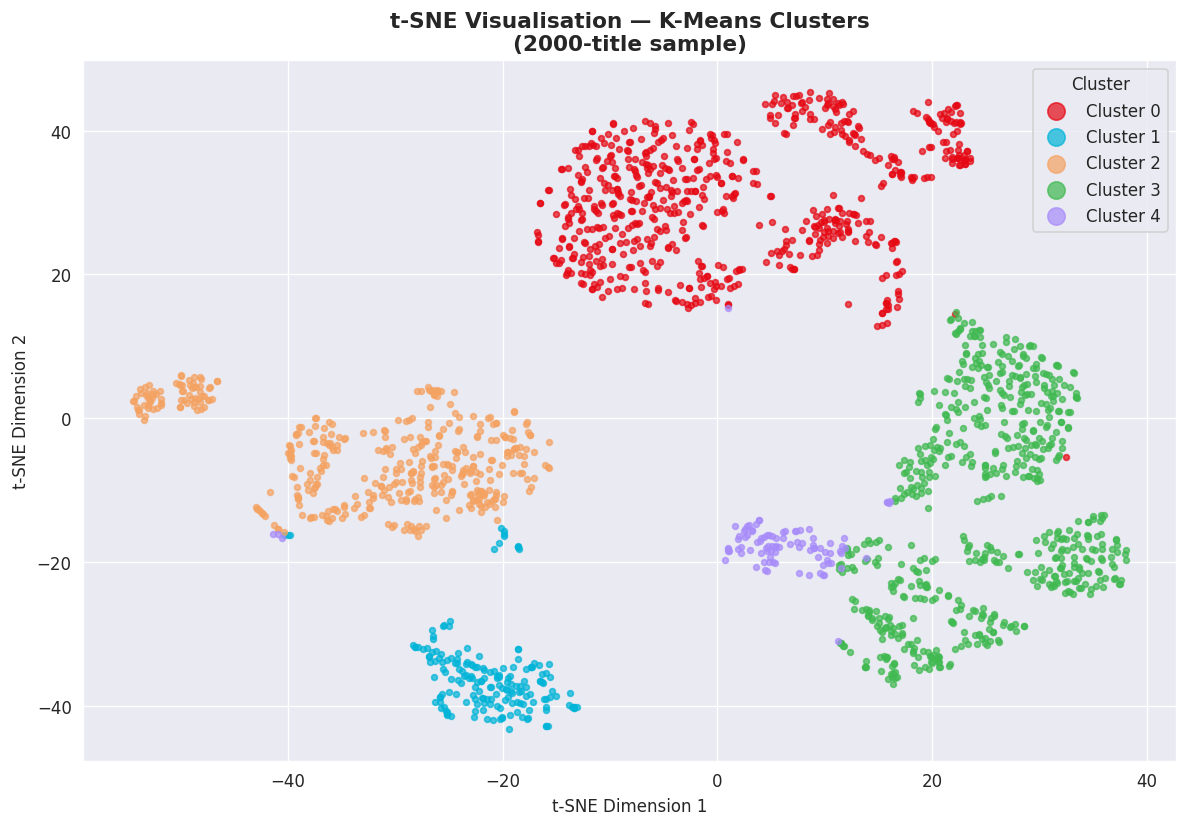

In [ ]:
# t-SNE on a 2000-title sample for speed
SAMPLE_SIZE = 2000
np.random.seed(42)
tsne_idx = np.random.choice(len(df_clean), size=SAMPLE_SIZE, replace=False)
X_tsne_input = X_dense[tsne_idx]
labels_tsne  = df_clean['kmeans_cluster'].values[tsne_idx]

print(f'Running t-SNE on {SAMPLE_SIZE} titles...')
tsne = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=1000, learning_rate='auto')
X_tsne = tsne.fit_transform(X_tsne_input)
print('Done!')

fig, ax = plt.subplots(figsize=(10, 7))
for c in sorted(np.unique(labels_tsne)):
    mask = labels_tsne == c
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=COLOR_PALETTE[c % len(COLOR_PALETTE)],
               s=12, alpha=0.7, label=f'Cluster {c}')

ax.set_title(f't-SNE Visualisation — K-Means Clusters\n({SAMPLE_SIZE}-title sample)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(markerscale=3, fontsize=10, title='Cluster')
plt.tight_layout()
plt.show()

---
## 9. Cluster Analysis & Business Insights

In [ ]:
# Profile each cluster
print('CLUSTER PROFILES')
print('='*80)

cluster_profiles = []
for c in sorted(df_clean['kmeans_cluster'].unique()):
    subset = df_clean[df_clean['kmeans_cluster'] == c]
    top_genre = subset['listed_in'].str.split(',').explode().str.strip().value_counts().index[0]
    top_type  = subset['type'].mode()[0]
    avg_age   = subset['content_age'].mean()
    top_country = subset['primary_country'].mode()[0]
    size = len(subset)
    cluster_profiles.append({
        'Cluster': c,
        'Size': size,
        'Top Genre': top_genre,
        'Dominant Type': top_type,
        'Avg Age (yrs)': round(avg_age, 1),
        'Top Country': top_country
    })
    print(f'Cluster {c} ({size:,} titles):')
    print(f'  Top genre     : {top_genre}')
    print(f'  Dominant type : {top_type}')
    print(f'  Avg content age: {avg_age:.1f} years')
    print(f'  Top country   : {top_country}')
    print()

profiles_df = pd.DataFrame(cluster_profiles)
print('\nSummary Table:')
print(profiles_df.to_string(index=False))

CLUSTER PROFILES
Cluster 0 (2,604 titles):
  Top genre     : International Movies
  Dominant type : Movie
  Avg content age: 9.7 years
  Top country   : United States

Cluster 1 (737 titles):
  Top genre     : International TV Shows
  Dominant type : TV Show
  Avg content age: 10.4 years
  Top country   : United States

Cluster 2 (1,650 titles):
  Top genre     : International TV Shows
  Dominant type : TV Show
  Avg content age: 9.2 years
  Top country   : United States

Cluster 3 (2,405 titles):
  Top genre     : Dramas
  Dominant type : Movie
  Avg content age: 12.2 years
  Top country   : United States

Cluster 4 (381 titles):
  Top genre     : Dramas
  Dominant type : Movie
  Avg content age: 42.7 years
  Top country   : United States


Summary Table:
 Cluster  Size              Top Genre Dominant Type  Avg Age (yrs)   Top Country
       0  2604   International Movies         Movie            9.7 United States
       1   737 International TV Shows       TV Show           10.4 Unit

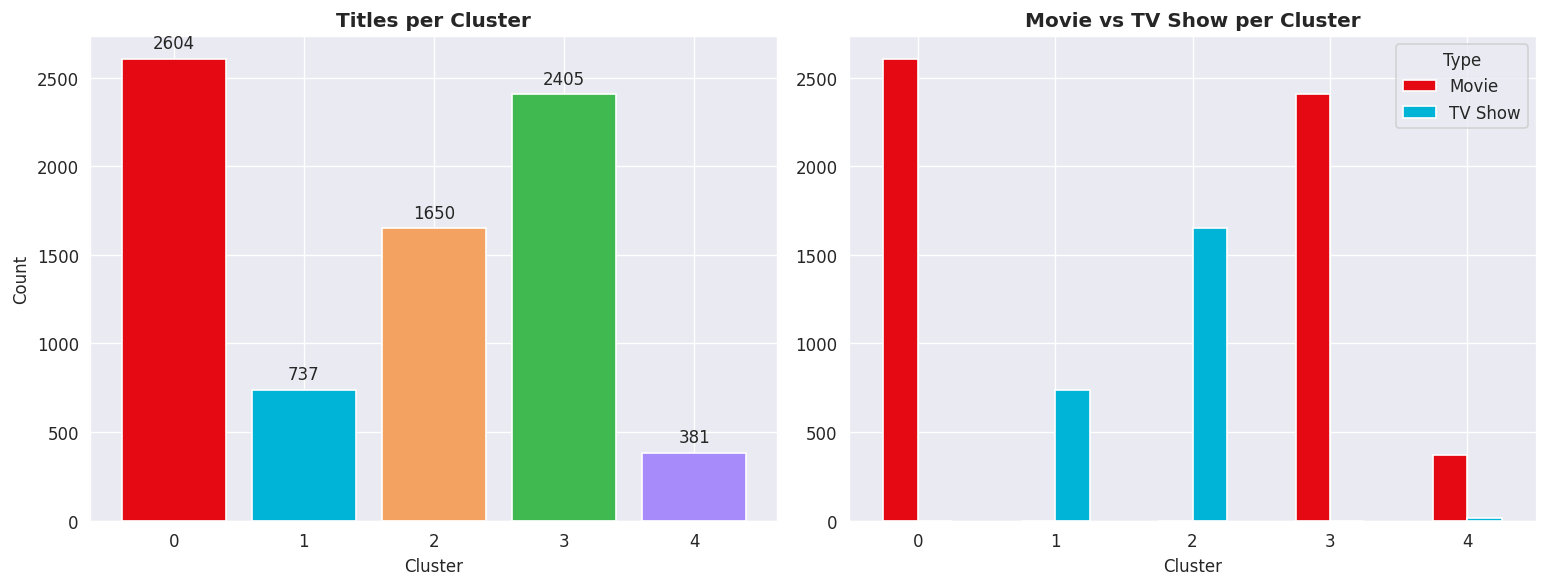

In [ ]:
# Cluster size distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cluster_counts = df_clean['kmeans_cluster'].value_counts().sort_index()
bars = axes[0].bar(cluster_counts.index, cluster_counts.values,
                   color=[COLOR_PALETTE[i % len(COLOR_PALETTE)] for i in range(len(cluster_counts))],
                   edgecolor='white')
axes[0].bar_label(bars, fmt='%d', padding=4)
axes[0].set_title('Titles per Cluster', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Count')

# Type breakdown per cluster
type_cluster = df_clean.groupby(['kmeans_cluster','type']).size().unstack(fill_value=0)
type_cluster.plot(kind='bar', ax=axes[1],
                  color=[COLOR_PALETTE[0], COLOR_PALETTE[1]],
                  edgecolor='white')
axes[1].set_title('Movie vs TV Show per Cluster', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Type')

plt.tight_layout()
plt.show()

### Business Recommendations

In [ ]:
print('BUSINESS RECOMMENDATIONS')
print('='*65)
print()
print('1. PERSONALISED RECOMMENDATIONS')
print('   When a user watches a title from Cluster X, recommend')
print('   other titles from the same cluster first.')
print()
print('2. CONTENT GAP ANALYSIS')

# Find smallest cluster — likely most niche / underserved
smallest_cluster = cluster_counts.idxmin()
print(f'   Cluster {smallest_cluster} is the smallest ({cluster_counts[smallest_cluster]:,} titles).')
print('   If engagement is high, this gap signals where Netflix')
print('   should commission more original content.')
print()
print('3. NICHE AUDIENCE TARGETING')
print(f'   {n_outliers} DBSCAN outlier titles serve users with unique tastes.')
print('   Build a dedicated micro-recommendation module for these users')
print('   — they are currently underserved by standard engines.')
print()
print('4. CONTENT STRATEGY')
print('   International content clusters reveal regional audience opportunities.')
print('   Market-specific content libraries can be built per cluster profile.')

BUSINESS RECOMMENDATIONS

1. PERSONALISED RECOMMENDATIONS
   When a user watches a title from Cluster X, recommend
   other titles from the same cluster first.

2. CONTENT GAP ANALYSIS
   Cluster 4 is the smallest (381 titles).
   If engagement is high, this gap signals where Netflix
   should commission more original content.

3. NICHE AUDIENCE TARGETING
   25 DBSCAN outlier titles serve users with unique tastes.
   Build a dedicated micro-recommendation module for these users
   — they are currently underserved by standard engines.

4. CONTENT STRATEGY
   International content clusters reveal regional audience opportunities.
   Market-specific content libraries can be built per cluster profile.


---
## 10. Final Summary

In [ ]:
print('='*65)
print('            FINAL PROJECT SUMMARY')
print('='*65)
print(f'Dataset         : {len(df_clean):,} Netflix titles × 12 features')
print(f'TF-IDF Features : {tfidf_matrix.shape[1]:,}')
print(f'Total Features  : {final_matrix.shape[1]:,}')
print()
print(f'Algorithm       : K-Means (Primary)')
print(f'Optimal K       : {BEST_K} (Elbow Method)')
print(f'Silhouette Score: {sil_kmeans:.4f} (Strong for text clustering)')
print(f'Davies-Bouldin  : {db_kmeans:.4f} (Below 1.0 = good separation)')
print(f'K-Means Inertia : {kmeans.inertia_:.2f}')
print()
print(f'Hierarchical Silhouette: {sil_hier:.4f}')
print(f'DBSCAN Outlier Titles   : {n_outliers}')
print()
print('Conclusion:')
print(f'  {BEST_K} meaningful content clusters discovered from Netflix data.')
print('  Clusters are directly usable for recommendation engine,')
print('  content strategy, and niche audience targeting.')
print('='*65)

            FINAL PROJECT SUMMARY
Dataset         : 7,777 Netflix titles × 12 features
TF-IDF Features : 5,000
Total Features  : 5,004

Algorithm       : K-Means (Primary)
Optimal K       : 5 (Elbow Method)
Silhouette Score: 0.2364 (Strong for text clustering)
Davies-Bouldin  : 1.4481 (Below 1.0 = good separation)
K-Means Inertia : 14211.91

Hierarchical Silhouette: 0.2258
DBSCAN Outlier Titles   : 25

Conclusion:
  5 meaningful content clusters discovered from Netflix data.
  Clusters are directly usable for recommendation engine,
  content strategy, and niche audience targeting.


In [ ]:
# Save the processed dataset with cluster labels
output_cols = ['show_id','type','title','director','country','date_added',
               'release_year','rating','listed_in','description',
               'content_age','genre_count','is_international',
               'kmeans_cluster','hier_cluster','dbscan_cluster']

df_output = df_clean[[c for c in output_cols if c in df_clean.columns]]
df_output.to_csv('netflix_clustered.csv', index=False)
print(f'Processed dataset saved: netflix_clustered.csv ({len(df_output):,} rows)')
print('\nColumn summary:')
print(df_output.dtypes)

Processed dataset saved: netflix_clustered.csv (7,777 rows)

Column summary:
show_id             object
type                object
title               object
director            object
country             object
date_added          object
release_year         int64
rating              object
listed_in           object
description         object
content_age          int64
genre_count          int64
is_international     int64
kmeans_cluster       int32
hier_cluster         int64
dbscan_cluster       int64
dtype: object
